# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

In [ ]:
# 1
'''
A model is linear when the variables that make up the model output a straight-line relationship.  That being said, it is linear in the output relationship.
'''

# 2
'''
The coefficient of the dummy variable is measuring the difference from some established baseline category.
The inclusion of a coefficient ommitts the baseline category, and the coefficient itself is telling you how much higher or lower than the baseline the outcome is.
'''

# 3
'''
Technically yes, linear regression can be used for classification, but it is not an ideal choice.
You could set a range of 0 to 1 with over/under 0.5 as the threshhold for the classifier, which would work for values between 0 and 1.
However, the model would also produce results outside of this range that would make no sense.
'''

# 4
'''
Some signs that a model is overfit include high success on the training data with low success on the test data,
as well as high sensitivity in the model for small changes in the data.
'''

# 5
'''
Multi-colinearity occurs when one predictor can be explained by other predictors.
Given multiple predictors, first regress one predictor on the others.
This creates a predictor with a part defined by the other predictors, as well as a unqiue section to this predictor.
In the model, use this unique section as a predictor, rather than the predictor itself.
'''

# 6
'''
As long as the relationship between terms in the model stays linear (added or subtracted),
you can incorporate nonlinear relationships between your target/response/dependent/outcome variable y and your features/control/response/independent variables x into your analysis.
'''

# 7
'''
The y-intercept is the predicted value of y when x is zero.
The slope coefficient is the change in y for a one-unit change in x.
The coefficient of the dummy variable is measuring the difference from that category to some established baseline category.
'''

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [19]:
# Load standard packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load the data

q1 = pd.read_csv('https://raw.githubusercontent.com/dylanmulieri/linear_models/refs/heads/main/data/Q1_clean.csv')

,Price
Neighbourhood,
Manhattan,183.664286
Staten Island,146.166667
Brooklyn,127.747378
Queens,96.857233
Bronx,75.276498


,Review Scores Rating
Neighbourhood,
Brooklyn,92.363497
Manhattan,91.801496
Bronx,91.654378
Queens,91.549057
Staten Island,90.843750


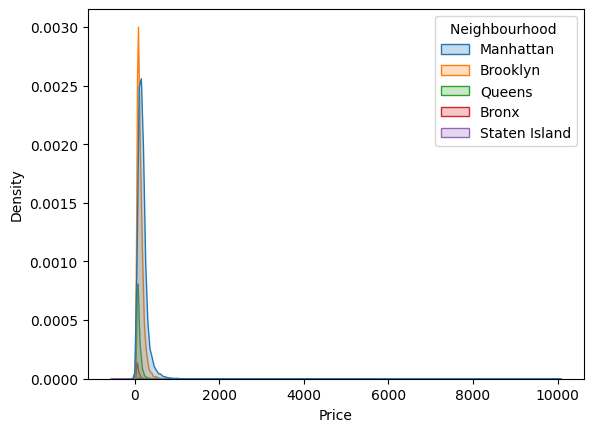

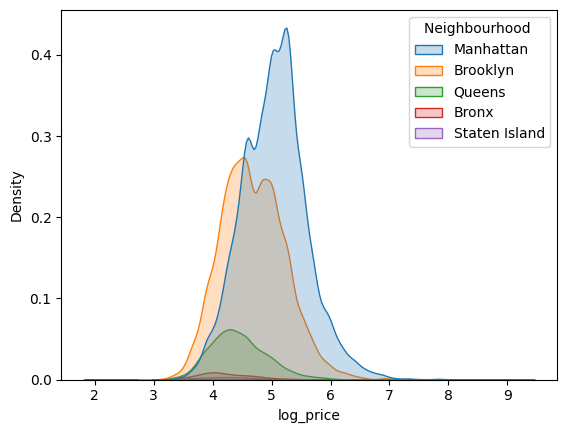

In [18]:
# 1
# Compute the average prices and scores by 'Neighbourhood '; which bourough is the most expensive on average?
# Create a kernel density plot of price and log price, grouping by 'Neighbourhood '.

# Average Price Calculation
display(q1.groupby('Neighbourhood ')['Price'].mean().sort_values(ascending=False))
# Manhattan is the most expensive on average

# Average Score Calculation
display(q1.groupby('Neighbourhood ')['Review Scores Rating'].mean().sort_values(ascending=False))

# KDE Plot of price and log price grouped by neighborhood
# Create log of price
q1['log_price'] = np.log(q1['Price'])

# KDE Plot of price and log price grouped by neighborhood
sns.kdeplot(data=q1, x='Price', hue='Neighbourhood ', fill=True)
plt.show()
sns.kdeplot(data=q1, x='log_price', hue='Neighbourhood ', fill=True)
plt.show()

In [28]:
# 2
'''
Regress price on Neighbourhood by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data.
Compare the coefficients in the regression to the table from part 1.
What pattern do you see?
What are the coefficients in a regression of a continuous variable on one categorical variable?
'''
# Create dummy
X = pd.get_dummies(q1['Neighbourhood '])
# lin reg
reg = LinearRegression(fit_intercept=False).fit(X, q1['Price'])
# results
print(pd.Series(reg.coef_, index=X.columns))

# The coefficients are equal to the group mean price
# Regressing a continuous variable on one categorical variable produces the group means

Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


In [27]:
# 3
'''
Repeat part 2, but leave an intercept in the linear model
How do you have to handle the creation of the dummies differently?
What is the intercept? Interpret the coefficients.
How can I get the coefficients in part 2 from these new coefficients?
'''
# Create dummy
X2 = pd.get_dummies(q1['Neighbourhood '], drop_first=True)
# lin reg
reg2 = LinearRegression().fit(X2, q1['Price'])
# results
print('Intercept:', reg3.intercept_.round(2))
print(pd.Series(reg2.coef_, index=X2.columns).round(2))

# One borough must be dropped to avoid perfect colinearity.
# The intercept is the mean price of this dropped borough.
# Subsequently, each coefficient is the price difference between that borough and the dropped borough.
# Add the intercept and coefficients to get the coefficients from part 2

Intercept: 75.28
Brooklyn          52.47
Manhattan        108.39
Queens            21.58
Staten Island     70.89
dtype: float64


In [46]:
# 4
'''
Split the sample 80/20 into a training and a test set.
Run a regression of Price on Review Scores Rating and Neighbourhood .
What is the  R2  and RMSE on the test set?
What is the coefficient on Review Scores Rating?
What is the most expensive kind of property you can rent?
'''

# Create dummy
X4 = pd.get_dummies(q1['Neighbourhood '], drop_first=True)
X4['Review Scores Rating'] = q1['Review Scores Rating'].values
# Split data 80/20 training/test
X4_tr, X4_te, y_tr, y_te = train_test_split(X4, q1['Price'], test_size=0.2, random_state=42)
# lin reg
reg4 = LinearRegression().fit(X4_tr, y_tr)
# results
print('R2:', round(r2_score(y_te, reg4.predict(X4_te)), 4))
print('RMSE:', round(np.sqrt(mean_squared_error(y_te, reg4.predict(X4_te))), 2))
print('ReviewScore coef:', round(reg4.coef_[-1], 4))

R2: 0.0459
RMSE: 140.92
ReviewScore coef: 1.2119
Series([], dtype: float64)


In [43]:
# 5
'''
Split the sample 80/20 into a training and a test set.
Run a regression of Price on Review Scores Rating and Neighbourhood and Property Type.
What is the  R2  and RMSE on the test set?
What is the coefficient on Review Scores Rating?
What is the most expensive kind of property you can rent?
'''
# Get dummy
X5 = pd.get_dummies(q1[['Neighbourhood ', 'Property Type']], drop_first=True)
X5['Review Scores Rating'] = q1['Review Scores Rating'].values
# Split data 80/20 training/test
X5_tr, X5_te, y_tr, y_te = train_test_split(X5, q1['Price'], test_size=0.2, random_state=42)
reg5 = LinearRegression().fit(X5_tr, y_tr)
# Results
print('R2:', round(r2_score(y_te, reg5.predict(X5_te)), 4))
print('RMSE:', round(np.sqrt(mean_squared_error(y_te, reg5.predict(X5_te))), 2))
print('ReviewScore coef:', round(reg5.coef_[-1], 4))
coefs5 = pd.Series(reg5.coef_[:-1], index=X5.columns[:-1])
print(coefs5.filter(like='Property Type').sort_values(ascending=False))
# Bungalow most expensive

R2: 0.0542
RMSE: 140.3
ReviewScore coef: 1.201
Property Type_Bungalow            83.972440
Property Type_Loft                69.891025
Property Type_Condominium         61.907162
Property Type_Other               49.249761
Property Type_Boat                47.070419
Property Type_Townhouse           44.110768
Property Type_House               34.711346
Property Type_Villa               33.901468
Property Type_Cabin               12.389621
Property Type_Treehouse           10.325182
Property Type_Camper/RV          -13.817125
Property Type_Bed & Breakfast    -28.703920
Property Type_Chalet             -30.237720
Property Type_Castle             -41.810548
Property Type_Dorm               -42.277758
Property Type_Lighthouse         -91.438731
Property Type_Hut               -134.604484
dtype: float64


In [ ]:
# 6
'''
What does the coefficient on Review Scores Rating mean if it changes from part 4 to 5?
Hint: Think about how multilple linear regression works.
'''
# response
'''
From part 4 to 5, the review coefficient changes from 1.2119 to 1.201, a small change.
This means that property type does not explain much of the variation in review score.
'''

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.